# GRA: rosenbrock tests

project = ```GRA```, host = ```chewie```, device = ```cuda:1```

## Goals:

Test these Lion extensions:

1. **relativistic**
2. **general relativistic**

Test on `rosenbrock` simulation

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [91]:
# HIDE CODE


from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D


def _cov_ellipse(mean_xy, cov, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = np.clip(vals[order], 0.0, None)
    vecs = vecs[:, order]

    width, height = 2.0 * n_std * np.sqrt(vals + 1e-20)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    return Ellipse(xy=mean_xy, width=width, height=height, angle=angle, **kwargs)


def plot_rosenbrock_trajectories(
        results,
        a: float = 1.0,
        *,
        every=10,
        contour=True,
        levels=40,
        k_tail=200,
        n_std=5.0,
        cmap="cividis",
        ellipse_color='C6',
        title="Rosenbrock trajectories (color = time)",
        zoom=None,  # None | float | ("tail", margin)
    ):
    
    rosenbrock_fn = get_rosenbrock_fun(a)
    x_opt, y_opt = float(a), float(a) ** 2

    names = list(results.keys())
    m = len(names)
    ncols = min(2, m)
    nrows = int(np.ceil(m / ncols))

    # ----- bounds (with optional zoom) -----
    if zoom is None:
        all_xy = np.concatenate([results[k] for k in names], axis=0)
        xmin, ymin = all_xy.min(axis=0)
        xmax, ymax = all_xy.max(axis=0)
        dx, dy = (xmax - xmin), (ymax - ymin)
        xmin -= 0.20 * dx
        xmax += 0.20 * dx
        ymin -= 0.20 * dy
        ymax += 0.20 * dy

    elif isinstance(zoom, (int, float)):
        z = float(zoom)
        xmin, xmax = x_opt - z, x_opt + z
        ymin, ymax = y_opt - z, y_opt + z

    else:
        mode, margin = zoom
        if mode != "tail":
            raise ValueError("zoom must be None, a float, or ('tail', margin)")
        margin = float(margin)

        tails = []
        for name in names:
            path = results[name]
            k = int(max(1, min(k_tail, len(path))))
            tails.append(path[-k:, :])
        tail_xy = np.concatenate(tails, axis=0)

        xmin, ymin = tail_xy.min(axis=0)
        xmax, ymax = tail_xy.max(axis=0)
        dx, dy = (xmax - xmin), (ymax - ymin)
        xmin -= margin * dx
        xmax += margin * dx
        ymin -= margin * dy
        ymax += margin * dy
    # --------------------------------------

    if contour:
        xs = np.linspace(xmin, xmax, 400)
        ys = np.linspace(ymin, ymax, 400)
        X, Y = np.meshgrid(xs, ys)
        Z = rosenbrock_fn(X, Y)
        Z = np.log10(Z + 1e-12)

    fig, axes = create_figure(
        nrows, ncols,
        figsize=(4 * ncols, 4 * nrows),
        sharex="all", sharey="all",
    )
    fig.suptitle(title)

    last_scatter = None

    for i, name in enumerate(names):
        ax = axes[i // ncols][i % ncols]
        path = results[name]
        T = path.shape[0]
        idx = np.arange(0, T, every)

        if contour:
            ax.contour(X, Y, Z, levels=levels, colors="0.75", linewidths=0.8, zorder=0)

        ax.plot(path[:, 0], path[:, 1], lw=0.8, color="0.2", alpha=0.35, zorder=1)

        last_scatter = ax.scatter(
            path[idx, 0], path[idx, 1],
            c=idx, s=12, cmap=cmap, linewidths=0, zorder=2
        )

        # start: empty black circle
        ax.scatter(
            path[0, 0], path[0, 1],
            s=80, marker="o",
            facecolors="none", edgecolors='k',
            linewidths=1.5, zorder=4,
        )

        # final: empty blue circle
        ax.scatter(
            path[-1, 0], path[-1, 1],
            s=300, marker="o",
            facecolors="none", edgecolors='blue',
            linewidths=1.5, zorder=4,
            alpha=0.4,
        )

        # tail mean + fluctuation ellipse
        k = int(max(1, min(k_tail, T)))
        tail = path[-k:, :]
        mean_xy = tail.mean(axis=0)
        ax.scatter(mean_xy[0], mean_xy[1], s=90, marker="x", color="red", linewidths=2.0, zorder=6)

        if k >= 2:
            cov = np.cov(tail.T, bias=False)
            ax.add_patch(_cov_ellipse(
                mean_xy, cov, n_std=n_std,
                facecolor="none", edgecolor=ellipse_color, linestyle="--", linewidth=1.2, zorder=3
            ))

        # optimum: cyan star
        ax.scatter(
            x_opt, y_opt,
            s=150, marker="*",
            facecolors="cyan",
            edgecolors="black",
            linewidths=1.5,
            zorder=6,
        )

        ax.set_title(name)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        if (i % ncols) == 0:
            ax.set_ylabel("y")
        if (i // ncols) == (nrows - 1):
            ax.set_xlabel("x")

    for j in range(m, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    fig.subplots_adjust(right=0.88, bottom=0.14, top=0.92)

    if last_scatter is not None:
        cax = fig.add_axes([1.04, 0.20, 0.02, 0.65])
        cbar = fig.colorbar(last_scatter, cax=cax)
        cbar.set_label("step")

    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="None", markerfacecolor="none",
               markeredgecolor="k", markeredgewidth=1.5, markersize=8, label="start"),
        Line2D([0], [0], marker="o", linestyle="None", markerfacecolor="none",
               markeredgecolor="blue", markeredgewidth=1.5, markersize=10, alpha=0.7, label="final"),
        Line2D([0], [0], marker="x", linestyle="None", color="red",
               markersize=8, markeredgewidth=2.0, label=f"mean(last {int(k_tail)})"),
        Line2D([0], [0], marker="*", linestyle="None", markerfacecolor="cyan", markeredgecolor='k',
               markersize=12, label=f"optimum ({a}, {a**2})"),
        Line2D([0], [0], linestyle="--", color=ellipse_color, linewidth=1.2,
               label=f"fluctuation ({n_std}σ ellipse)"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04), ncol=5, frameon=False
    )

    plt.show()

In [83]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

In [84]:
from optimzers import *
from test.test import *


def get_rosenbrock_fun(a: float = 1.0):
    def _rosenbrock(x, y):
        return (a - x)**2 + 100 * (y - x**2)**2

    return _rosenbrock


def run_experiment(optimizer_cls, kwargs, a=1.0, steps=1_000):
    # Start at a tricky point
    params = torch.tensor([-1.5, -1.0], requires_grad=True)
    opt = optimizer_cls([params], **kwargs)
    rosenbrock = get_rosenbrock_fun(a)

    path = []
    losses = []
    
    for _ in range(steps):
        opt.zero_grad()
        loss = rosenbrock(params[0], params[1])
        loss.backward()
        opt.step()
        
        path.append(params.detach().numpy().copy())
        losses.append(loss.item())
        
    return np.array(path), losses

## rosenbrock test 1

`a = 1`

In [157]:
%%time

a = 1.0
expt_kws = dict(a=a, steps=10_000)

lr = 1e-2
betas = (0.9, 0.999)


path_adam, loss_adam = run_experiment(
    torch.optim.Adam, {'lr': lr, 'betas': betas}, **expt_kws)

path_lion, loss_lion = run_experiment(
    Lion, {'lr': lr}, **expt_kws)

path_rel_lion, loss_rel_lion = run_experiment(
    RelativisticLion, {'lr': lr, 'mass': 10000.0}, **expt_kws)

path_rel_adam, loss_rel_adam = run_experiment(
    RelativisticAdam, {'lr': lr, 'mass':1000.0, 'betas': betas}, **expt_kws)

CPU times: user 9.44 s, sys: 0 ns, total: 9.44 s
Wall time: 9.44 s


In [158]:
k = 10

print(f"\nFinal Loss Adam: {smooth_1d(loss_adam, k=k)[-1]:.6f}")
print(f"Final Loss Lion: {smooth_1d(loss_lion, k=k)[-1]:.6f}")
print(f"Final Loss Relativistic Lion: {smooth_1d(loss_rel_lion, k=k)[-1]:.6f}")
print(f"Final Loss Relativistic Adam: {smooth_1d(loss_rel_adam, k=k)[-1]:.6f}\n")

Final Loss Adam: 0.000000

Final Loss Lion: 0.560157

Final Loss Relativistic Lion: 0.000000

Final Loss Relativistic Adam: 0.000000

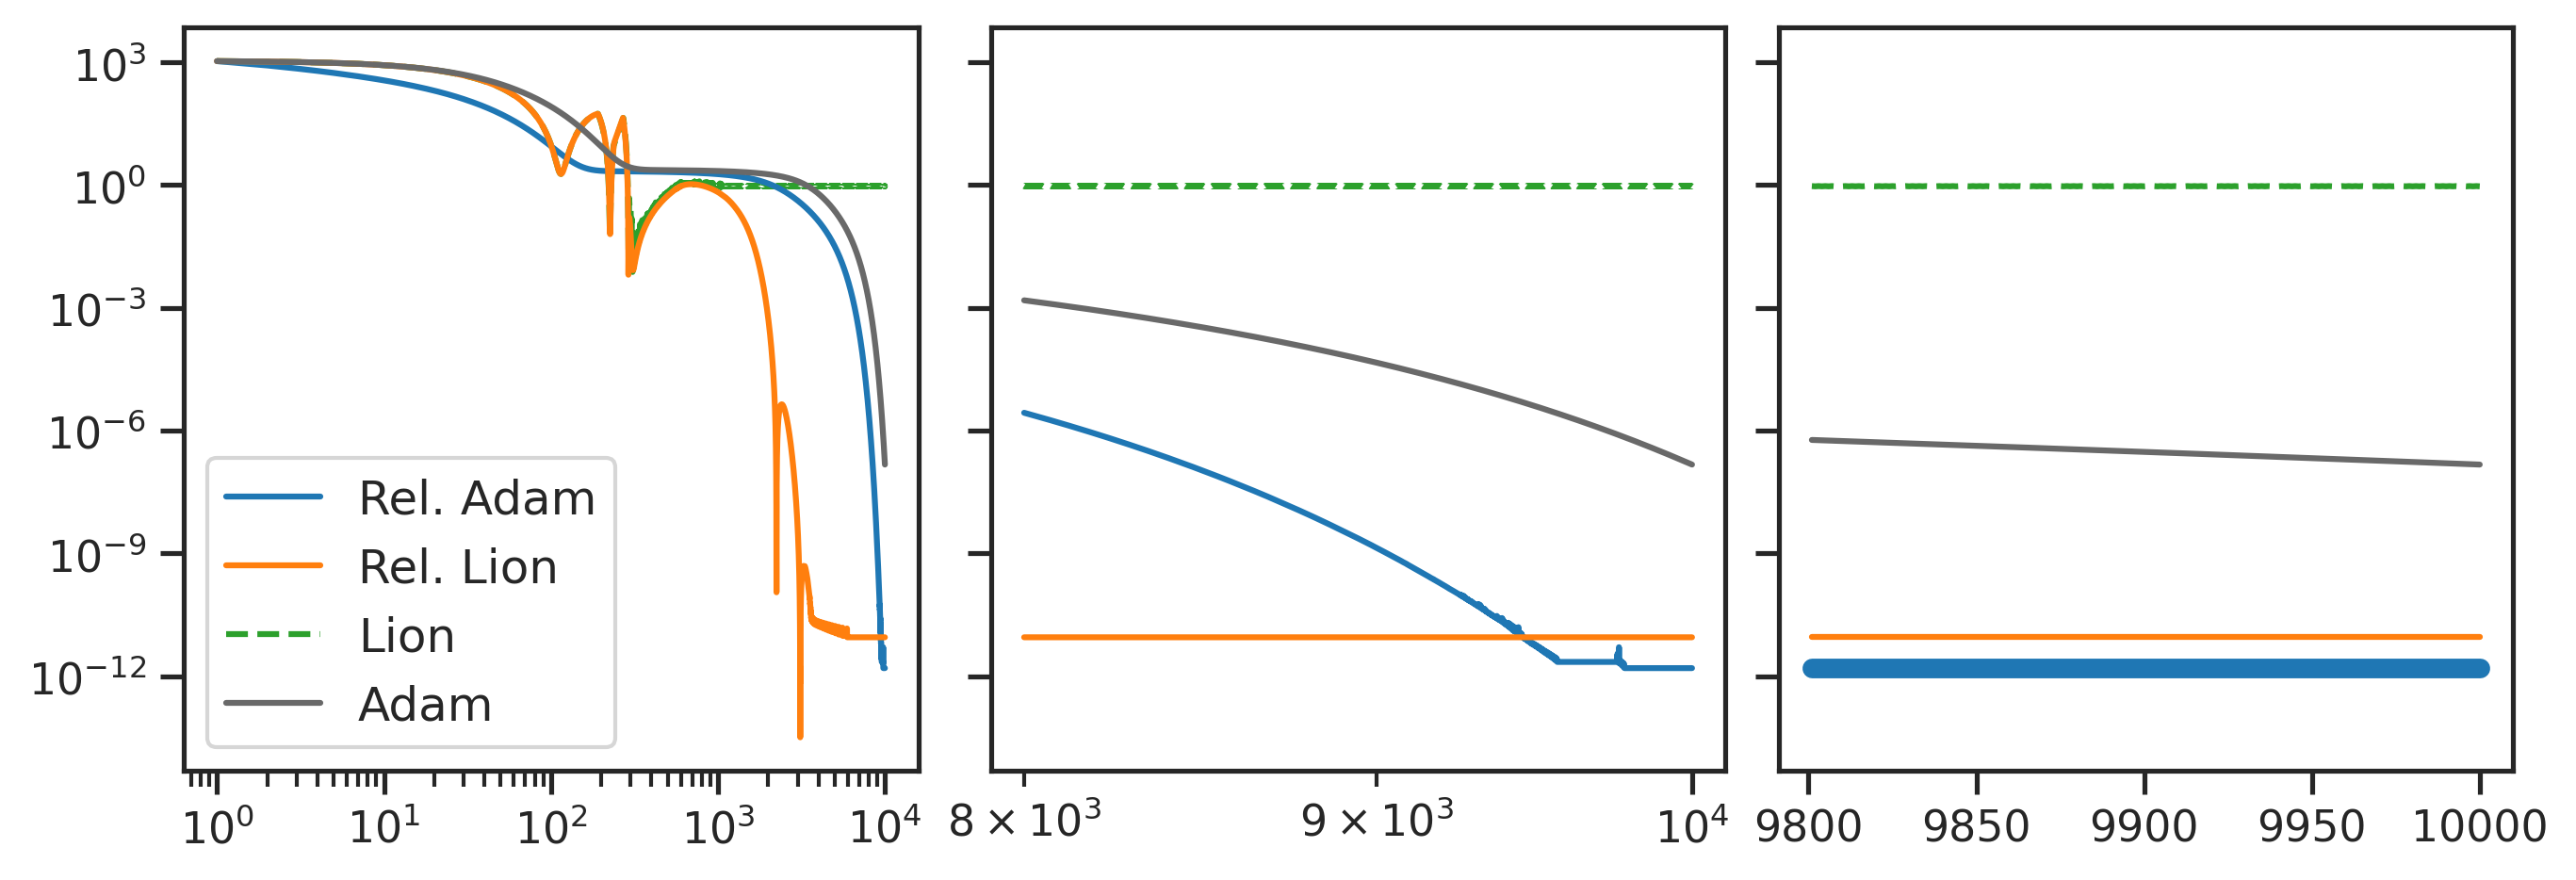

In [159]:
invls = [slice(None), slice(-2000, None), slice(-200, None)]

n = len(loss_adam)
x = np.arange(1, n + 1)

fig, axes = create_figure(1, 3, (9, 3), sharey="row", dpi=300)
for i, (ax, intvl) in enumerate(zip(axes, invls)):
    if i == len(invls) - 1:
        ax.semilogy(x[intvl], loss_rel_adam[intvl], label="Rel. Adam", lw=5)
        ax.semilogy(x[intvl], loss_rel_lion[intvl], label="Rel. Lion")
        ax.semilogy(x[intvl], loss_lion[intvl], label="Lion", ls="--", zorder=-1)
        ax.semilogy(x[intvl], loss_adam[intvl], label="Adam", color="dimgrey")
    else:
        ax.loglog(x[intvl], loss_rel_adam[intvl], label="Rel. Adam")
        ax.loglog(x[intvl], loss_rel_lion[intvl], label="Rel. Lion")
        ax.loglog(x[intvl], loss_lion[intvl], label="Lion", ls="--", zorder=-1)
        ax.loglog(x[intvl], loss_adam[intvl], label="Adam", color="dimgrey")

axes[0].legend(fontsize=12)
plt.show()

In [160]:
results_to_plot = {
    "Adam": path_adam,
    "Lion": path_lion,
    "Relativistic Lion": path_rel_lion,
    "Relativistic Adam": path_rel_adam,
}

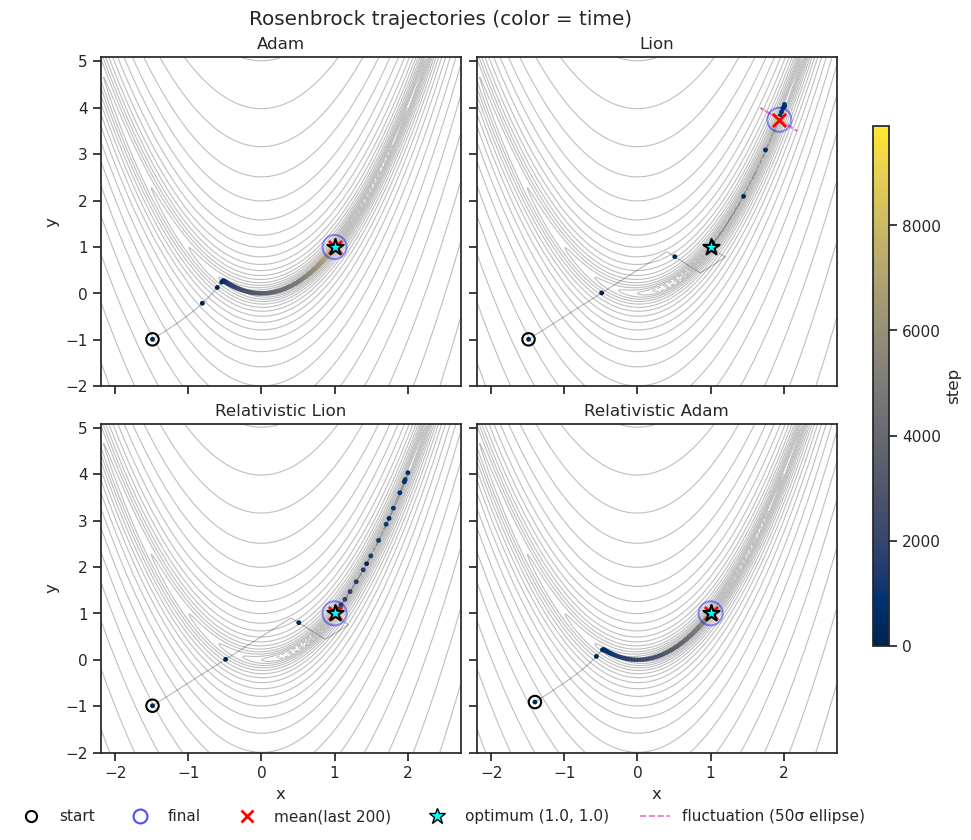

In [161]:
plot_rosenbrock_trajectories(results_to_plot, a=a, every=100, contour=True, n_std=50)

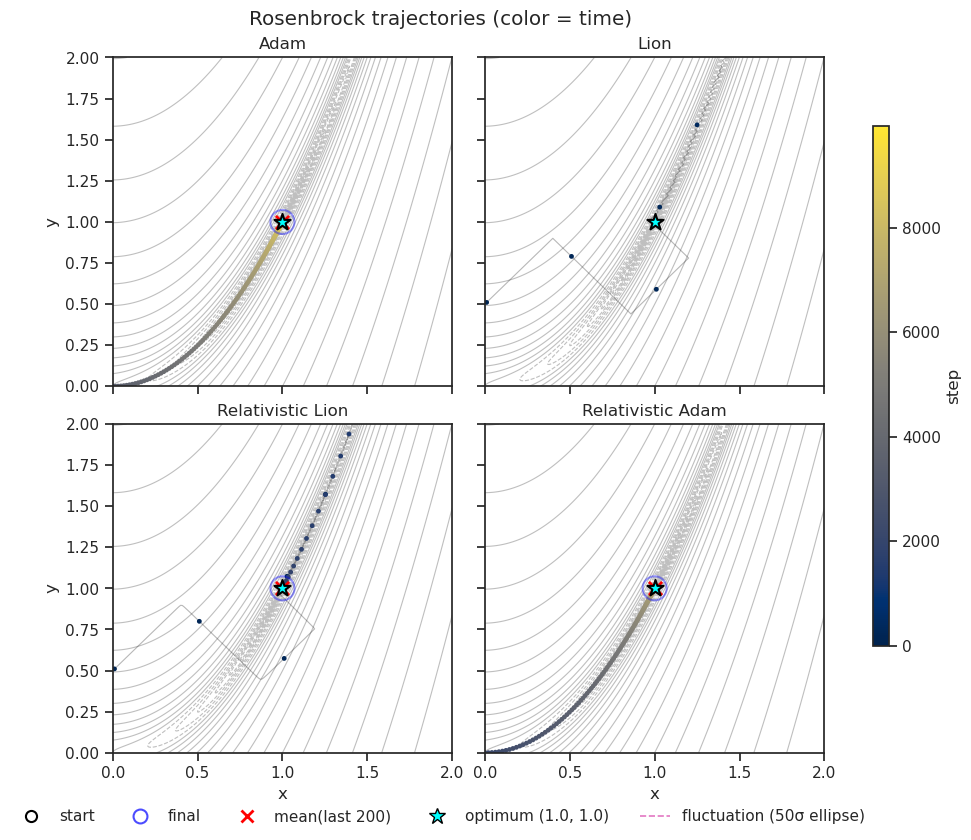

In [162]:
plot_rosenbrock_trajectories(results_to_plot, a=a, every=50, contour=True, zoom=True, n_std=50)